### Retrieving the core flow from geomagnetic measures using _physics-informed neural networks_ (PiNNs)

In [1]:
%pip install pygeodyntools --upgrade

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import numpy
import scipy
import pygeotools
import matplotlib.pyplot as plt
import tqdm
import time
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import math
import torch.nn.functional as F

In [3]:
# Setting the seed
torch.manual_seed(0)
torch.use_deterministic_algorithms(True)

### 0) Useful parameters

In [4]:
time_of_study: int = 2020       # Time of the study

number_of_inputs: int = 2       # Number of input variables (θ and φ angles)
number_of_outputs: int = 3      # Number of output variables (uθ, uφ, br)

number_of_layers: int = 5       # Number of layers
number_of_neurons: int = 32     # Number of neurons

number_epochs: int = 10000      # Number of epochs

fine_tune: bool = True          # Fine-tuning the model using L-BFGS?
number_steps: int = 500         # Number of steps for the fine tuning

grid_size: int = 3              # Using 3deg per 3deg grid

patch: tuple = (0, 180, 0, 360)   # Defining the patch

use_synthetic_sv: bool = True   # Do we use a synthetic SV?

estimate_small_scale_br: bool = False # Do we estimate the small-scales of Br?

filter_br: bool = False          # Do we filter Br?
σ_filter_br: float = 1

filter_sv: bool = False
σ_filter_sv = 1

λ_dbrdt = 1
λ_br = 1
λ_tg = 1e4
λ_tor = 0
λ_wn = 1e-4
λ_sn = 0
λ_spec_u = 1

losses: dict = {                # The different losses to use (available: misfit_dbrdt, misfit_br, tangential_geostrophy, weak_norm, strong_norm, vorticity)
    # "misfit_dbrdt": λ_dbrdt,
    # "misfit_br": λ_br,
    # "tangential_geostrophy": λ_tg,
    # "weak_norm": λ_wn,
    "spectral_u": λ_spec_u
}

### 1) Retrieving the data from geodynamo simulations

In [5]:
# Initializing the library
pygeo = pygeotools.pygeotools()

# Defining the path and the name of the model
model_path = "geodynamo.hdf5"
model_name = "model_geodynamo"

# Loading the model
pygeo.loadModel(model_name, "pygeodyn_hdf5", model_path)

# Defining the grid for computing the fields
# It is 3°x3° angular grid
if not pygeo.isGrid(f"{grid_size}deg"):
    pygeo.addGrid(f"{grid_size}deg", grid_size, grid_size)

# Setting the grid
pygeo.setGrid(f"{grid_size}deg")

# Retrieving the angles
_, (thetas, phis) = pygeo.getCurrentGrid()

# Defining the context for computing the SV and MF, and U
context_sv = {"lmax": 13, "r": pygeo.constants["rCore"]}
context_mf = {"lmax": 13, "r": pygeo.constants["rCore"]}
context_u = {"lmax": 18, "r": pygeo.constants["rCore"]}

# Computing the fields
SV = pygeo.addMeasure(model_name, "SV", context_sv)
MF = pygeo.addMeasure(model_name, "MF", context_mf)
U = pygeo.addMeasure(model_name, "U", context_u)

# Retrieving the times
times = pygeo.getQuantity(model_name, "times")

# Retrieving the associated times index
idx_times = numpy.argmin(numpy.abs(times - time_of_study))

# Retrieving the components of the fields
dbrdt_obs = SV[idx_times, ..., 0]
br_obs = MF[idx_times, ..., 0]
dbrdth_obs = numpy.gradient(br_obs, thetas, axis=0)
dbrdph_obs = numpy.gradient(br_obs, phis, axis=1)
uθ_obs = U[idx_times, ..., 1]
uφ_obs = U[idx_times, ..., 2]

# Storing into the observations dict
observations = {
    "dbrdt": dbrdt_obs, "br": br_obs, "uth": uθ_obs, "uph": uφ_obs, "dbrdth": dbrdth_obs, "dbrdph": dbrdph_obs
}

pygeotools was initialized with `verbose=True`.
13


In [6]:
# Computing the spectrum associated with the observed flow (mean)

# Retrieving the coefficients
coeffs = pygeo.getQuantity(model_name, "U")

kmax = coeffs.shape[-1] // 2

tnm = coeffs[...,:kmax]
snm = coeffs[...,kmax:]

# Keeping the coefficients up to l = 18
ktrunc = 18 * (18 + 2)

tnm = tnm[...,:ktrunc]
snm = snm[...,:ktrunc]

# Creating the array for the spectra
S = numpy.zeros((tnm.shape[0], 18 + 1))

k = 0

# Computing the spectrum at each time
for l in range(1, 18 + 1):
    N = (l * (l + 1) / (2 * l + 1))
    for m in range(0, l + 1):
        S[..., l] += N * (tnm[...,k]**2 + snm[...,k]**2)
        k += 1

        if m != 0:
            S[..., l] += N * (tnm[...,k]**2 + snm[...,k]**2)
            k += 1

# Defining the observed spectrum
S_u_obs = S[idx_times,...]

### 1 bis) Generating synthetic SV

In [7]:
r = 3480.

In [8]:
if use_synthetic_sv:

    # Creating synthetic data
    θ = thetas
    φ = phis

    θ_grid, φ_grid = numpy.meshgrid(θ, φ, indexing="ij")

    sinθ = numpy.sin(θ_grid).clip(1e-1, 1)
    cosθ = numpy.cos(θ_grid)

    dθ = numpy.gradient(θ).mean()
    dφ = numpy.gradient(φ).mean()

    dΩ = sinθ * dθ * dφ

    duθdθ = numpy.gradient(uθ_obs, θ, axis=0)
    duθdφ = numpy.gradient(uθ_obs, φ, axis=1)
    duφdθ = numpy.gradient(uφ_obs, θ, axis=0)
    duφdφ = numpy.gradient(uφ_obs, φ, axis=1)

    divh_uh= (1 / (r * sinθ)) * (duθdθ * sinθ + uθ_obs * cosθ + duφdφ)

    dbrdth = numpy.gradient(br_obs, θ, axis=0)
    dbrdph = numpy.gradient(br_obs, φ, axis=1)

    observations["dbrdth"] = dbrdth
    observations["dbrdph"] = dbrdph

    gradθbr = dbrdth / r
    gradφbr = dbrdph / (r * sinθ)

    br_divh_uh = br_obs * divh_uh
    uh_dot_gradbr = uθ_obs * gradθbr + uφ_obs * gradφbr

    dbrdt = -(br_divh_uh + uh_dot_gradbr)

    # Overwriting the dbrdt observation
    observations["dbrdt"] = dbrdt

### 2) Defining the network architecture

In [9]:
class Network(torch.nn.Module):

    def __init__(self, nb_input: int, nb_output: int, nb_layer: int, nb_neuron: int) -> None:
        
        # Initializing the torch module
        super(Network, self).__init__()

        # Initializing the layers
        layers = []

        # Creating the first layer
        layers.append(torch.nn.Linear(nb_input, nb_neuron))
        layers.append(torch.nn.Tanh())

        # Creating the hidden layers
        for _ in range(nb_layer):
            layers.append(torch.nn.Linear(nb_neuron, nb_neuron))
            layers.append(torch.nn.Tanh())

        # Creating the last layer
        layers.append(torch.nn.Linear(nb_neuron, nb_output))

        # Creating the network
        self.net: torch.nn.Sequential = torch.nn.Sequential(*layers)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.net(inputs)

In [10]:
# Defining the network instance
network_instance = Network(number_of_inputs, number_of_outputs, number_of_layers, number_of_neurons)

### 3) Creating the tensors

In [11]:
# Function to create a tensor from a numpy array
def as_tensor(numpy_array: numpy.ndarray, requires_grad: bool = False) -> torch.Tensor:
    return torch.tensor(numpy_array, dtype=torch.float32, requires_grad=requires_grad)

# Function to create an autograd tensor from a tensor
def as_grad(tensor: torch.Tensor, input: torch.Tensor) -> torch.Tensor:
    return torch.autograd.grad(tensor, input, torch.ones_like(tensor), retain_graph=True, create_graph=True)[0]

In [12]:
# Converting back the angles in degrees
thetas_deg: numpy.ndarray = numpy.round(numpy.rad2deg(thetas), 3)
phis_deg: numpy.ndarray = numpy.round(numpy.rad2deg(phis), 3)

# Retrieving the corresponding indexes for the patch
idx_theta_min = numpy.argmin(numpy.abs(thetas_deg - patch[0]))
idx_theta_max = numpy.argmin(numpy.abs(thetas_deg - patch[1]))
idx_phi_min = numpy.argmin(numpy.abs(phis_deg - patch[2]))
idx_phi_max = numpy.argmin(numpy.abs(phis_deg - patch[3]))

# Avoiding conflict with the slice end
idx_theta_max = None if idx_theta_max + 1 == len(thetas_deg) else idx_theta_max + 1
idx_phi_max = None if idx_phi_max + 1 == len(phis_deg) else idx_phi_max + 1

# Defining the slices (to ease the notation afterwards)
slice_thetas = slice(idx_theta_min, idx_theta_max, 1)
slice_phis = slice(idx_phi_min, idx_phi_max, 1)

# Creating the grid
thetas_grid, phis_grid = numpy.meshgrid(thetas, phis, indexing="ij")

# Defining the tensors from the observations
tensors = {}

# Looping over all observations
for name in observations:
    field = observations[name][slice_thetas, slice_phis].reshape(-1, 1)
    tensors[name] = torch.tensor(field, dtype=torch.float32)

# Defining the angular grid tensor
thetas_tensor = as_tensor(thetas_grid[slice_thetas, slice_phis].reshape(-1, 1), requires_grad=True)
phis_tensor = as_tensor(phis_grid[slice_thetas, slice_phis].reshape(-1, 1), requires_grad=True)

# Updating the list of tensors
tensors.update({
    "thetas": thetas_tensor, "phis": phis_tensor
})

# Defining the input tensor
input_tensor = torch.concatenate([thetas_tensor, phis_tensor], dim=1)

In [13]:
S_u_obs_tensor = as_tensor(S_u_obs[1:])

In [14]:
field_shape = phis_grid[slice_thetas, slice_phis].shape

### 4) Defining the loss function

In [15]:
# Filter method
def gaussian_filter_2d_torch(input, sigma, truncate=3):
    """
    Applying a 2-d Gaussian filter on a map
        - (tensor) `input` the input tensor
        - (int) `sigma` the standard deviation for the Gaussian kernel
        - (int) `truncate` truncate the filter at this many standard deviation
    """

    if len(input.shape) == 2 and input.shape[-1] == 1:
        input = input.reshape(observations["br"][slice_thetas, slice_phis].shape)

    # Computing the kernel size
    kernel_size = 2 * math.ceil(sigma * truncate) + 1

    # Creating the 1-d kernel
    x = torch.arange(kernel_size).float()  - (kernel_size - 1) / 2
    kernel_1d = torch.exp(-(x / sigma)**2 / 2)
    kernel_1d /= kernel_1d.sum()

    # Creating the 2-d kernel
    kernel_2d =  torch.outer(kernel_1d, kernel_1d)

    # Formatting the kernel for the conv2d layer (H, W) -> (B = 1, C = 1, H, W)
    kernel_2d = kernel_2d.unsqueeze(0).unsqueeze(0)

    # Applying the 2-d convolution
    output = F.conv2d(input.unsqueeze(0).unsqueeze(0), kernel_2d, padding="same")

    # Removing the batch (B) and channel (C) dimensions
    return output.squeeze(0).squeeze(0).reshape(-1, 1)

In [16]:
# Computing the spherical harmonics
def spherical_harmonics(lmax, thetas, phis):
    # Defining the degrees and modes
    l = numpy.arange(0, lmax + 1, 1)
    m = l[::]

    # Creating the meshing
    θ, φ = numpy.meshgrid(thetas, phis, indexing="ij")
    L, M = numpy.meshgrid(l, m, indexing="ij")

    # Computing the unormalized associated Legendre polynomials
    # (restricting to m >= 0)
    z = numpy.cos(θ)
    p, *_ = scipy.special.assoc_legendre_p_all(lmax, lmax, z, branch_cut=2, diff_n=0)
    p = p[:, :(lmax + 1), ...]

    def dirac(x):
        return numpy.float64(x == 0)
    
    def fact(x):
        return numpy.float64(scipy.special.factorial(x, exact=False, extend="zero"))

    # Computing Schmidt quasi-normalisation
    schmidt_norm = numpy.sqrt((2 - dirac(M)) * fact(L - M) / fact(L + M))

    # Adding the norm
    p = numpy.einsum('ij,ijkl->ijkl', schmidt_norm, p, optimize=True)

    # Defining cos(mφ) and sin(mφ)
    mφ = numpy.einsum('ij,kl->ijkl', M, φ, optimize=True)
    cos_mφ = numpy.cos(mφ)
    sin_mφ = numpy.sin(mφ)

    # Defining the real spherical harmonics
    y_cos = cos_mφ * p
    y_sin = sin_mφ * p

    return y_cos, y_sin

In [17]:
# Pre-computing the basis functions
y_cos, y_sin = spherical_harmonics(18, thetas, phis)

# Converting into tensors
y_cos_tensor = as_tensor(y_cos[..., slice_thetas, slice_phis])
y_sin_tensor = as_tensor(y_sin[..., slice_thetas, slice_phis])

In [18]:
import opt_einsum

# Method for computing the Gauss coefficients
def spectral_transform(field: torch.Tensor, l_trunc: int = 18) -> tuple:
    l = torch.arange(0, l_trunc + 1, 1)

    # Surely redundant... but faster
    thetas_tensor = as_tensor(thetas)
    phis_tensor = as_tensor(phis)

    # Meshing the angles and degrees
    θ, φ = torch.meshgrid(thetas_tensor, phis_tensor, indexing="ij")
    L, M = torch.meshgrid(l, l, indexing="ij")

    # Defining the surface element
    dθ = numpy.gradient(thetas).mean()
    dφ = numpy.gradient(phis).mean()
    sinθ = torch.sin(θ)
    dΩ = sinθ * dθ * dφ

    # Defining the normalisation constant for the Gauss coefficient
    C = (2 * L + 1) / (4 * numpy.pi)

    # Decomposing the field
    coeffs_cos = torch.einsum('ijkl,kl,ij->ij', y_cos_tensor, field * dΩ, C)
    coeffs_sin = torch.einsum('ijkl,kl,ij->ij', y_sin_tensor, field * dΩ, C)

    return coeffs_cos, coeffs_sin

In [ ]:
# Function for computing the loss function
def compute_loss(input: torch.Tensor, return_fields: bool = False) -> tuple | torch.Tensor:

    # Defining the outer core radius
    r = torch.tensor(pygeo.constants["rCore"], dtype=torch.float32)
    
    # Retrieving the predictions from the network
    predictions = network_instance(input)

    # Separating between the flow components and br
    # Here, the flow components are toroidal and poloidal scalar fields, t and s
    t: torch.Tensor = predictions[...,0:1]
    s: torch.Tensor = predictions[...,1:2]
    br: torch.Tensor = predictions[...,2:3]

    # Retrieving the observations
    dbrdt_obs: torch.Tensor = tensors["dbrdt"]
    br_obs: torch.Tensor = tensors["br"]

    # Computing the derivatives of the observed Br (in we are estimating the small-scales)
    if estimate_small_scale_br:
        dbrdθ_obs = tensors["dbrdth"]
        dbrdφ_obs = tensors["dbrdph"]

    # Retrieving angles (ensuring gradient calculations)
    θ: torch.Tensor = tensors["thetas"]
    φ: torch.Tensor = tensors["phis"]

    # Defining useful quantities
    sinθ: torch.Tensor = torch.sin(θ).clamp(1e-1, 1)
    cosθ: torch.Tensor = torch.cos(θ)

    # Defining the derivatives of t and s
    dtdθ: torch.Tensor = as_grad(t, θ)
    dtdφ: torch.Tensor = as_grad(t, φ)
    dsdθ: torch.Tensor = as_grad(s, θ)
    dsdφ: torch.Tensor = as_grad(s, φ)

    # Retrieving uθ and uφ
    uθ: torch.Tensor = (1 / sinθ) * dtdφ + dsdθ
    uφ: torch.Tensor = -dtdθ + (1 / sinθ) * dsdφ

    # 1) Computing the SV

    # Defining the equation of induction
    # We have: dbr / dt = -divh(uh br) = -br divh(uh) - uh ⋅  gradh(br)

    # Computing the derivatives of uθ and uφ
    duθdθ: torch.Tensor = as_grad(uθ, θ)
    duθdφ: torch.Tensor = as_grad(uθ, φ)
    duφdθ: torch.Tensor = as_grad(uφ, θ)
    duφdφ: torch.Tensor = as_grad(uφ, φ)

    # Computing the derivatives of br
    dbrdθ: torch.Tensor = as_grad(br, θ)
    dbrdφ: torch.Tensor = as_grad(br, φ)

    # Computing divh(uh)
    divh_uh: torch.Tensor = (1 / (r * sinθ)) * (duθdθ * sinθ + uθ * cosθ + duφdφ)

    # Computing gradh(br)
    if estimate_small_scale_br:
        gradθ_br: torch.Tensor = (1 / r) * (dbrdθ + dbrdθ_obs)
        gradφ_br: torch.Tensor = (1 / (r * sinθ)) * (dbrdφ + dbrdφ_obs)

        dbrdt = -((br + br_obs) * divh_uh + gradθ_br * uθ + gradφ_br * uφ)
    else:
        gradθ_br: torch.Tensor = (1 / r) * dbrdθ
        gradφ_br: torch.Tensor = (1 / (r * sinθ)) * dbrdφ

        dbrdt = -(br * divh_uh + gradθ_br * uθ + gradφ_br * uφ)

    # 2) Computing the loss functions

    # Defining the total loss function
    total_loss: torch.Tensor = torch.tensor(0, dtype=torch.float32)

    if "misfit_dbrdt" in losses:
        if filter_sv:
            dbrdt_pred = gaussian_filter_2d_torch(input=dbrdt, sigma=σ_filter_sv)
            dbrdt_obs_filter = gaussian_filter_2d_torch(dbrdt_obs, sigma=σ_filter_sv)
        else:
            dbrdt_pred = dbrdt
            dbrdt_obs_filter = dbrdt_obs

        misfit_dbrdt: torch.Tensor = (dbrdt_pred - dbrdt_obs_filter).pow(2).mean() / dbrdt_obs_filter.pow(2).mean()
        loss = losses["misfit_dbrdt"] * misfit_dbrdt
        total_loss += loss

        saved_losses["misfit_dbrdt"].append(loss.clone().detach().numpy())

    if "misfit_br" in losses:
        if filter_br:
            br_pred = gaussian_filter_2d_torch(br, sigma=σ_filter_br)
            br_obs_filter = gaussian_filter_2d_torch(br_obs, sigma=σ_filter_br)
        else:
            br_pred = br
            br_obs_filter = br_obs

        misfit_br: torch.Tensor = (br_pred - br_obs_filter).pow(2).mean() / br_obs_filter.pow(2).mean()
        loss = losses["misfit_br"] * misfit_br
        total_loss += loss

        saved_losses["misfit_br"].append(loss.clone().detach().numpy())

    if "tangential_geostrophy" in losses:
        tangential_geostrophy: torch.Tensor = (cosθ * divh_uh - sinθ * uθ / r).pow(2).mean()
        loss = losses["tangential_geostrophy"] * tangential_geostrophy
        total_loss += loss

        saved_losses["tangential_geostrophy"].append(loss.clone().detach().numpy())

    if "toroidal" in losses:
        toroidal: torch.Tensor = divh_uh.pow(2).mean()
        loss = losses["toroidal"] * toroidal
        total_loss += loss

        saved_losses["toroidal"].append(loss.clone().detach().numpy())

    if "weak_norm" in losses:
        dθ = numpy.gradient(thetas).mean()
        dφ = numpy.gradient(phis).mean()
        dΩ = sinθ * dθ * dφ

        weak_norm: torch.Tensor = torch.sum((uθ**2 + uφ**2) * dΩ) / torch.sum(dΩ)

        loss = losses["weak_norm"] * weak_norm
        total_loss += loss

        saved_losses["weak_norm"].append(loss.clone().detach().numpy())

    if "strong_norm" in losses:
        dθ = numpy.gradient(thetas).mean()
        dφ = numpy.gradient(phis).mean()
        dΩ = sinθ * dθ * dφ

        d2uθdθ: torch.Tensor = as_grad(duθdθ, θ)
        d2uθdφ: torch.Tensor = as_grad(duθdφ, φ)
        d2uφdθ: torch.Tensor = as_grad(duφdθ, θ)
        d2uφdφ: torch.Tensor = as_grad(duφdφ, φ)

        Δuθ = (1 / (r**2 * sinθ)) * (cosθ * duθdθ + sinθ * d2uθdθ) + (1 / (r * sinθ)**2) * d2uθdφ
        Δuφ = (1 / (r**2 * sinθ)) * (cosθ * duφdθ + sinθ * d2uφdθ) + (1 / (r * sinθ)**2) * d2uφdφ

        strong_norm: torch.Tensor = torch.sum((Δuθ**2 + Δuφ**2) * dΩ) / torch.sum(dΩ)

        loss = losses["strong_norm"] * strong_norm
        total_loss += loss

        saved_losses["strong_norm"].append(loss.clone().detach().numpy())

    if "frozen_br" in losses:
        dθ = numpy.gradient(thetas).mean()
        dφ = numpy.gradient(phis).mean()
        dΩ = sinθ * dθ * dφ

        frozen_br: torch.Tensor = torch.sum(torch.abs(br) * dΩ) / torch.sum(dΩ)

        loss = losses["frozen_br"] * frozen_br
        total_loss += loss

        saved_losses["frozen_br"].append(loss.clone().detach().numpy())

    if "spectral_u" in losses:
        
        # Reshaping the toroidal and poloidal fields
        t_field = t.reshape(field_shape)
        s_field = s.reshape(field_shape)

        # Computing the spectrum of the fields
        coeffs_cos_tor, coeffs_sin_tor = spectral_transform(t_field, 18)
        coeffs_cos_pol, coeffs_sin_pol = spectral_transform(s_field, 18)

        # Computing the kinetic energy spectrum
        S_u_pred = torch.zeros((18))

        # Computing the spectrum
        for l in range(1, 18 + 1):
            c = l * (l + 1) / (2 * l + 1)
            for m in range(0, l + 1):
                S_u_pred[l-1] += c * (coeffs_cos_tor[l,m]**2 + coeffs_sin_tor[l,m]**2 + coeffs_cos_pol[l,m]**2 \
                             + coeffs_sin_pol[l,m]**2)
                
        # Comparing the two spectra
        ΔS = ((S_u_obs_tensor - S_u_pred) / S_u_obs_tensor).pow(2).sum()

        loss = losses["spectral_u"] * ΔS
        total_loss += loss

        saved_losses["spectral_u"].append(loss.clone().detach().numpy())

    # 3) Returning the results

    if return_fields:
        return dbrdt.clone().detach().numpy(), \
            uθ.clone().detach().numpy(), uφ.clone().detach().numpy(), br.clone().detach().numpy(), \
            t.clone().detach().numpy(), s.clone().detach().numpy()
    
    return total_loss

### 5) Training the network

In [23]:
# To store the losses
saved_losses = {name: [] for name in losses}

In [24]:
# Initializing the optimizer
optimizer = torch.optim.Adam(network_instance.parameters())

# Initializing the layers
with torch.no_grad():
    outputs_layer: torch.nn.Linear = network_instance.net[-1]
    torch.nn.init.xavier_normal_(outputs_layer.weight)
    outputs_layer.weight[2].data.fill_(1e5)

# The lower loss so far
lower_loss = 1e99

# Starting time
start_time = time.time()

# Creating the bar format for the progress bar
leftmost_bar = "\r{desc}: {percentage:3.0f}% | "
rightmost_bar = " | {n_fmt}/{total_fmt} [{remaining} remaining, {rate_fmt}] ; Loss = {postfix[0]:.2E}"
center_bar: str = "{bar:10}"

network_instance.train()

# Starting the training
with tqdm.tqdm(total=number_epochs, bar_format=f"{leftmost_bar}{center_bar}{rightmost_bar}", postfix=[lower_loss]) as progress:

    # Looping over all epochs
    for epoch in range(number_epochs):

        # Optimization step
        optimizer.zero_grad()
        loss = compute_loss(input_tensor)
        loss.backward()
        optimizer.step()
        
        # If the current loss is lower, we are saving the model
        if loss < lower_loss:
            lower_loss = float(loss.detach().clone())
            progress.postfix[0] = lower_loss
            torch.save(network_instance.state_dict(), "best_model.pt")

        # Updating the progress bar
        progress.update()

# Ending time
end_time = time.time()

# At the end of the training, we are retrieving the best model
network_instance.load_state_dict(torch.load("best_model.pt"))

  0% |            | 2/10000 [21:24 remaining,  7.78it/s] ; Loss = 1.65E+01

tensor(17.0230, grad_fn=<SumBackward0>)
tensor(16.4669, grad_fn=<SumBackward0>)


  0% |            | 4/10000 [20:09 remaining,  8.26it/s] ; Loss = 1.49E+01

tensor(15.7721, grad_fn=<SumBackward0>)
tensor(14.9408, grad_fn=<SumBackward0>)


  0% |            | 6/10000 [20:10 remaining,  8.26it/s] ; Loss = 1.29E+01

...

tensor(2.7614, grad_fn=<SumBackward0>)
tensor(2.8558, grad_fn=<SumBackward0>)


  0% |            | 24/10000 [20:32 remaining,  8.09it/s] ; Loss = 1.93E+00

tensor(2.8469, grad_fn=<SumBackward0>)
tensor(2.7729, grad_fn=<SumBackward0>)


  0% |            | 24/10000 [19:46 remaining,  8.41it/s] ; Loss = 1.93E+00


KeyboardInterrupt: 

In [ ]:
# Adding some fine-tuning with L-BFGS
if fine_tune:

    optimizer = torch.optim.LBFGS(network_instance.parameters())

    # Defining the closure function (mandatory for L-BFGS)
    def closure():
        optimizer.zero_grad()
        loss = compute_loss(input_tensor)
        loss.backward()
        return loss

    # Starting the training
    with tqdm.tqdm(total=number_steps, bar_format=f"{leftmost_bar}{center_bar}{rightmost_bar}", postfix=[lower_loss]) as progress:

        # Reload the best model
        network_instance.load_state_dict(torch.load("best_model.pt"))

        # Looping over all epochs
        for epoch in range(number_steps):

            # Optimization step
            loss = optimizer.step(closure)
            
            # If the current loss is lower, we are saving the model
            if loss < lower_loss:
                lower_loss = float(loss.detach().clone())
                progress.postfix[0] = lower_loss
                torch.save(network_instance.state_dict(), "best_model.pt")

            # Updating the progress bar
            progress.update()

# At the end of the training, we are retrieving the best model
network_instance.load_state_dict(torch.load("best_model.pt"))

  0% |            | 0/500 [? remaining, ?it/s] ; Loss = 3.55E-01C:\Users\romai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\optim\lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  loss = float(closure())
100% | ██████████ | 500/500 [00:00 remaining,  2.05s/it] ; Loss = 6.08E-02


<All keys matched successfully>

### 6) Some stats

In [ ]:
print(f"The training took {end_time - start_time} seconds.")
print(f"The best model has a loss = {lower_loss:.2E}.")

The training took 1287.9907140731812 seconds.
The best model has a loss = 6.08E-02.


### 7) Retrieving the predicted fields

In [ ]:
# Retrieving the observations
dbrdt_obs = observations["dbrdt"][slice_thetas, slice_phis]
uθ_obs = observations["uth"][slice_thetas, slice_phis]
uφ_obs = observations["uph"][slice_thetas, slice_phis]
br_obs = observations["br"][slice_thetas, slice_phis]

network_instance.eval()

# Retrieving the predictions
dbrdt_tensor_pred, \
uθ_tensor_pred, \
uφ_tensor_pred, \
br_tensor_pred, \
t_tensor_pred, \
s_tensor_pred = compute_loss(input_tensor, True)

# Reshaping the fields
dbrdt_pred = dbrdt_tensor_pred.reshape(dbrdt_obs.shape)
uθ_pred = uθ_tensor_pred.reshape(uθ_obs.shape)
uφ_pred = uφ_tensor_pred.reshape(uθ_obs.shape)
br_pred = br_tensor_pred.reshape(uθ_obs.shape)

# Saving
predictions = {
    "dbrdt": dbrdt_pred, "uth": uθ_pred, "uph": uφ_pred, "br": br_pred
}

### 8) Maps

In [ ]:
# Folder
import os

folder = f"experiments/"

os.makedirs(folder, exist_ok=True)

In [ ]:
# The name of the quantity we want to map
name = "uth"

In [ ]:
# Defining the grid in longitudes and latitudes
latitudes = pygeo.convertThetasToLatitudes(thetas)
longitudes = pygeo.convertPhisToLongitudes(phis)

lat_grid_full, long_grid_full = numpy.meshgrid(latitudes, longitudes, indexing="ij")

lat_grid = lat_grid_full[slice_thetas, slice_phis]
long_grid = long_grid_full[slice_thetas, slice_phis]

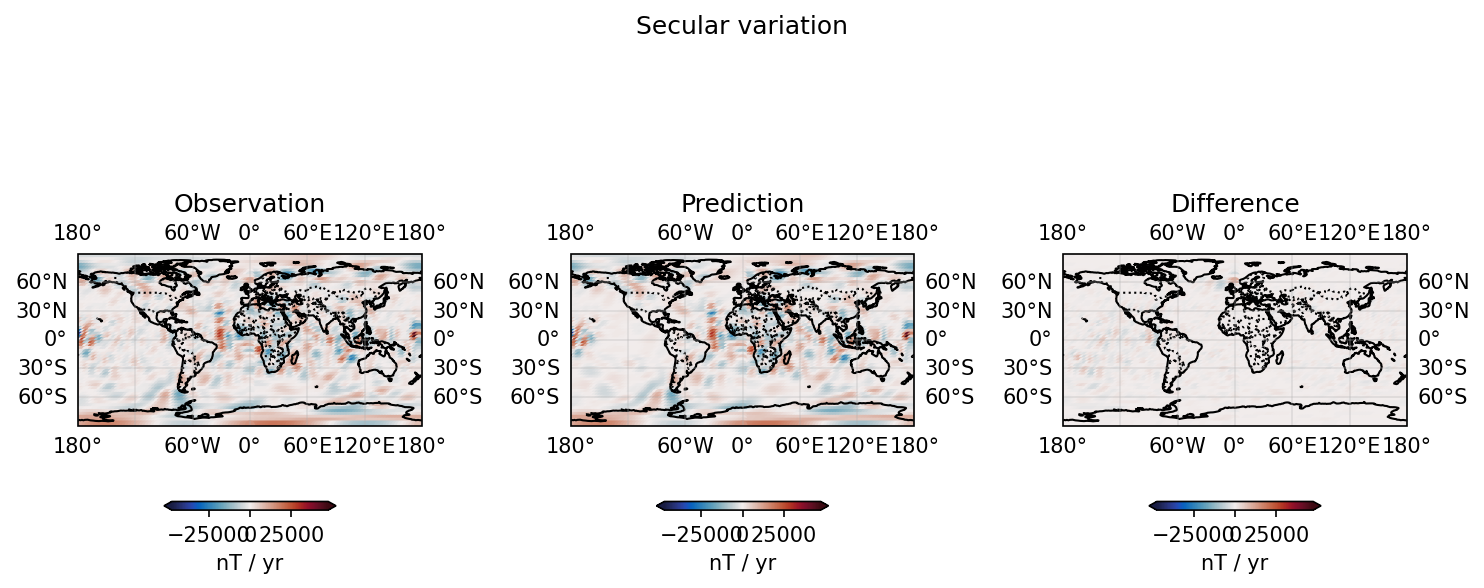

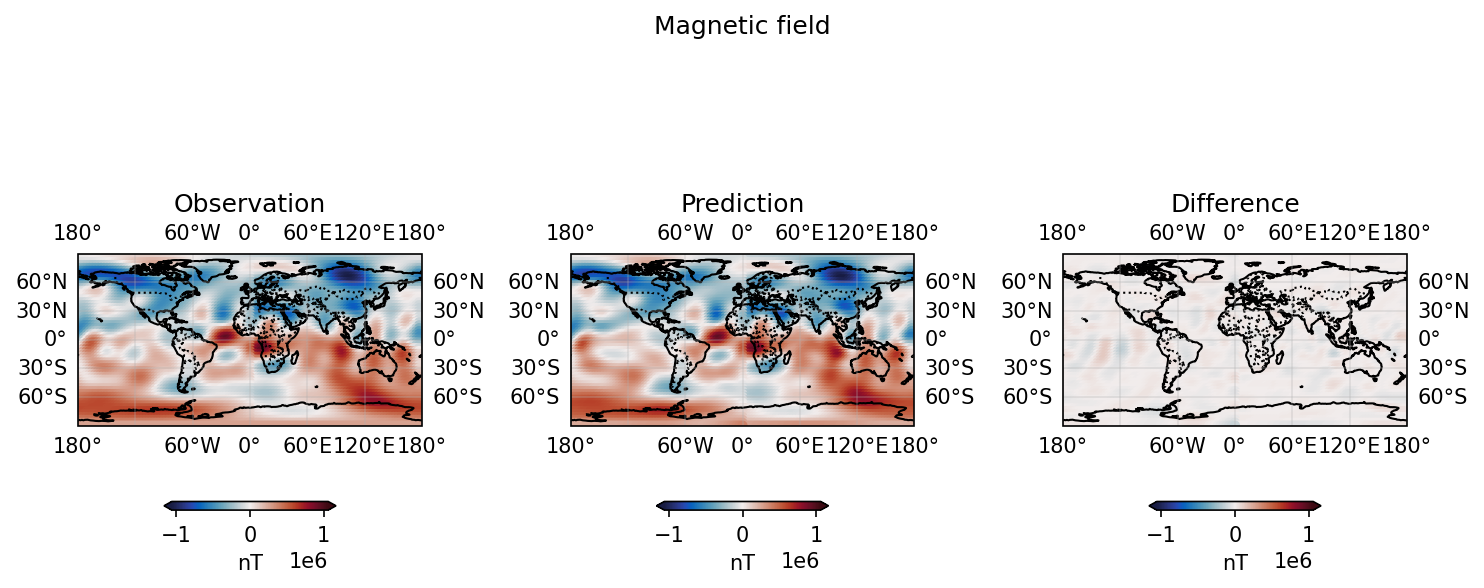

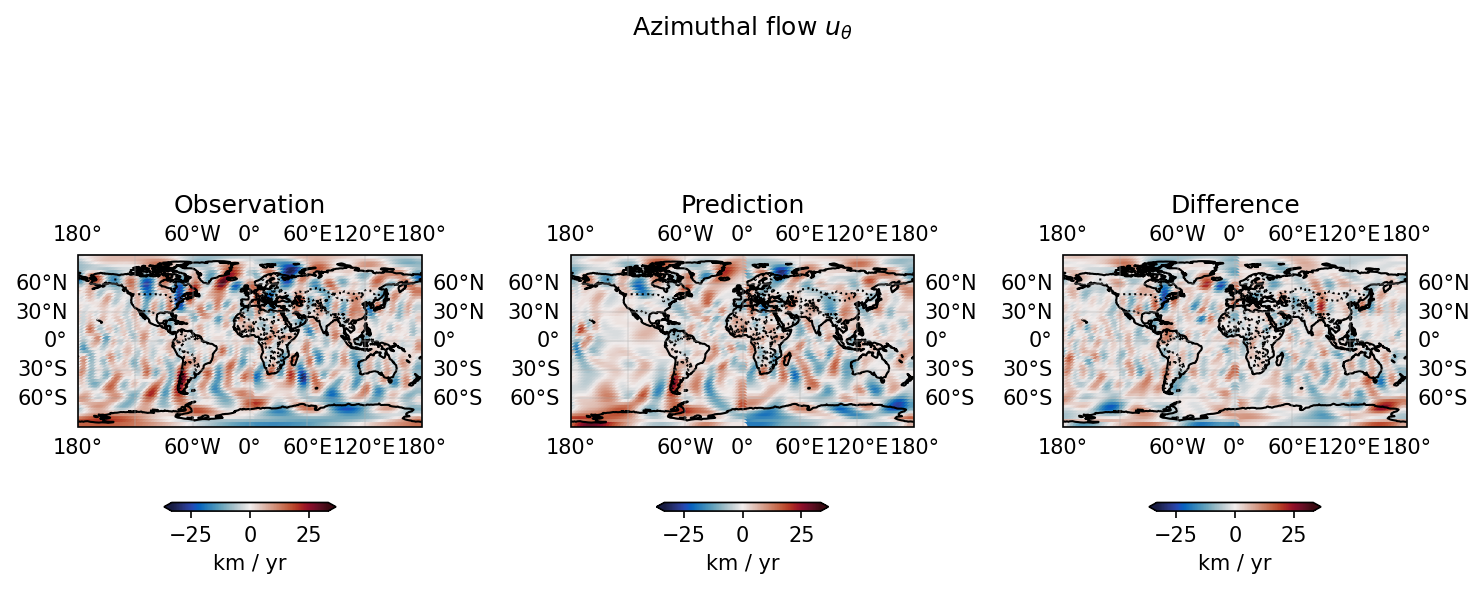

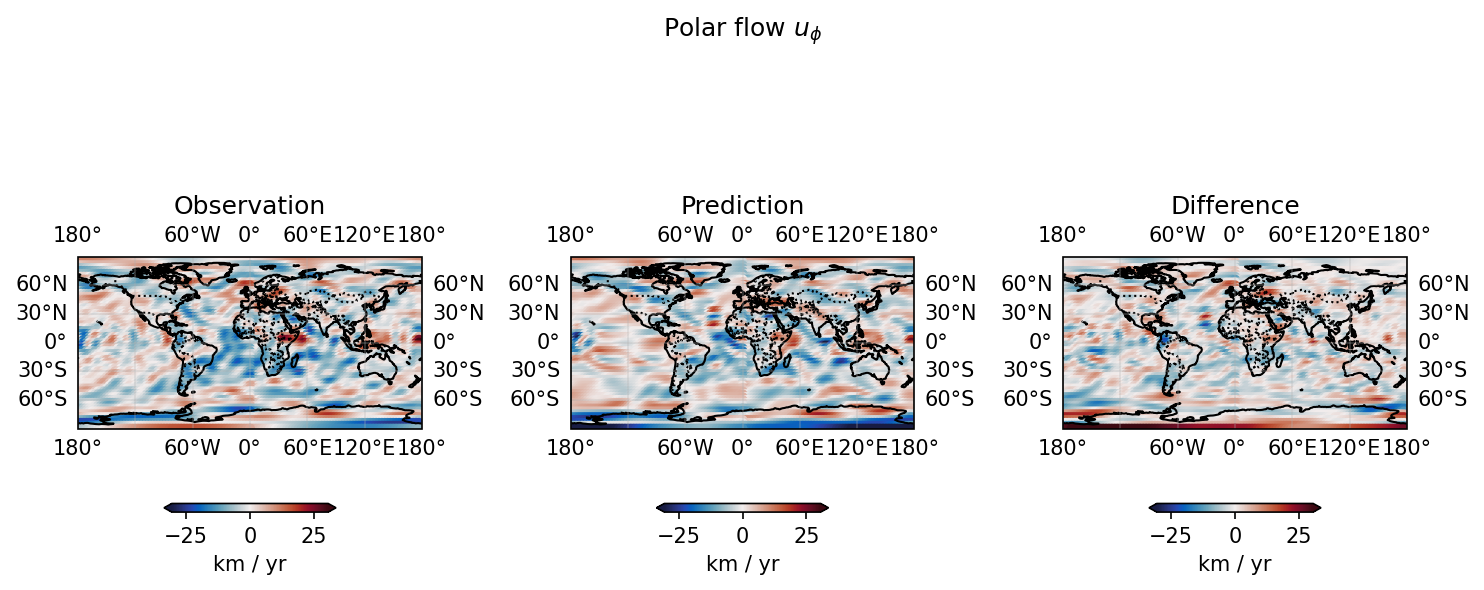

In [ ]:
# Titles, suptitles and units
titles = ["Observation", "Prediction", "Difference"]
units = {"dbrdt": "nT / yr", "br": "nT", "uth": "km / yr", "uph": "km / yr"}
suptitles = {"dbrdt": "Secular variation", "br": "Magnetic field", "uth": "Azimuthal flow $u_\\theta$", "uph": "Polar flow $u_\\phi$"}

for name in ["dbrdt", "br", "uth", "uph"]:

    fig, axes = plt.subplots(1, 3, subplot_kw={'projection': ccrs.PlateCarree()}, sharex=True, sharey=True, figsize=(10, 4), dpi=150)

    obs = observations[name][slice_thetas, slice_phis]
    pred = predictions[name]

    # Maximum value took by the observations
    vmax = numpy.max(numpy.abs(obs))

    # Arguments for the plot
    kwargs = {"cmap": cmocean.cm.balance, "vmin": -vmax, "vmax": vmax, "s": 15, "marker": "o"}

    cb1 = axes[0].scatter(long_grid, lat_grid, c=obs, **kwargs)
    cb2 = axes[1].scatter(long_grid, lat_grid, c=pred, **kwargs)
    cb3 = axes[2].scatter(long_grid, lat_grid, c=obs - pred, **kwargs)

    # axes[0].contour(long_grid, lat_grid, obs, colors=['black'], levels=10, linewidths=1, linestyles="solid")
    # axes[1].contour(long_grid, lat_grid, pred, colors=['black'], levels=10, linewidths=1, linestyles="solid")

    for n, ax in enumerate(axes):
        ax.coastlines(resolution='110m')
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.3)
        ax.set_title(titles[n])

    cbar = plt.colorbar(cb1, orientation="horizontal", shrink=0.5, extend="both")
    cbar2 = plt.colorbar(cb2, orientation="horizontal", shrink=0.5, extend="both")
    cbar3 = plt.colorbar(cb3, orientation="horizontal", shrink=0.5, extend="both")

    cbar.set_label(units[name])
    cbar2.set_label(units[name])
    cbar3.set_label(units[name])

    plt.suptitle(suptitles[name])

    fig.tight_layout()
    fig.savefig(f"{folder}{name}.png")

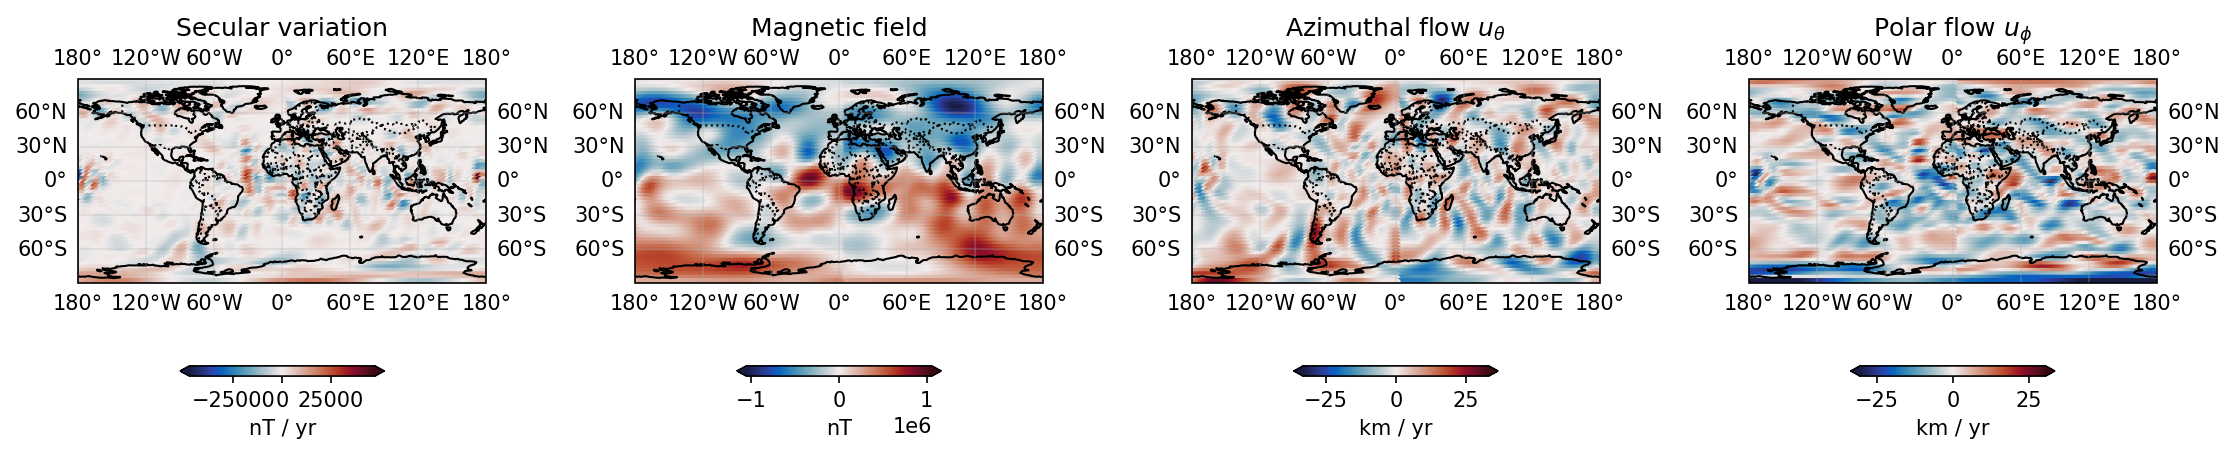

In [ ]:
maps = ["dbrdt", "br", "uth", "uph"]

fig, axes = plt.subplots(1, len(maps), subplot_kw={'projection': ccrs.PlateCarree()}, sharex=True, sharey=True, figsize=(15, 4), dpi=150)

for n, map in enumerate(maps):
    pred = predictions[map]
    obs = observations[map]

    # Maximum value took by the observations
    vmax = numpy.max(numpy.abs(obs))

    # Arguments for the plot
    kwargs = {"cmap": cmocean.cm.balance, "vmin": -vmax, "vmax": vmax, "s": 15, "marker": "o"}

    cb = axes[n].scatter(long_grid, lat_grid, c=pred, **kwargs)

    # axes[n].contour(long_grid, lat_grid, pred, colors=['black'], levels=10, linewidths=1, linestyles="solid")

    axes[n].coastlines(resolution='110m')
    axes[n].add_feature(cfeature.BORDERS, linestyle=':')
    axes[n].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.3)
    axes[n].set_title(suptitles[map])

    cbar = plt.colorbar(cb, orientation="horizontal", shrink=0.5, extend="both")

    cbar.set_label(units[map])

plt.tight_layout()
plt.savefig(f"{folder}predictions.png")

### 9) Losses

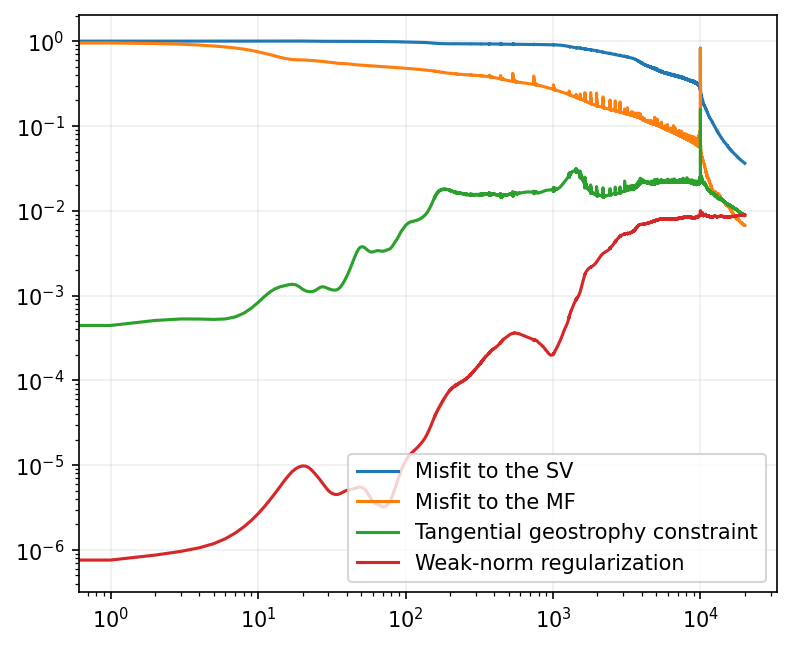

In [ ]:
labels = {
    "misfit_dbrdt": "Misfit to the SV",
    "misfit_br": "Misfit to the MF",
    "tangential_geostrophy": "Tangential geostrophy constraint",
    "toroidal": "Toroidality constraint",
    "weak_norm": "Weak-norm regularization",
    "strong_norm": "Strong-norm regularization",
    "frozen_br": "Frozen-flux hypothesis on Br",
    "spectral_u": "Spectral kinetic energy condition on the flow"
}

fig, ax = plt.subplots(1, 1, figsize=(6, 5), dpi=150)

for name in saved_losses:
    ax.loglog(saved_losses[name], label=labels[name])

ax.grid(alpha=0.2)
ax.legend()

fig.savefig(f"{folder}losses.png")

### 10) Diagnostics

In [ ]:
name = "uth"

obs = observations[name][slice_thetas, slice_phis]
pred = predictions[name]
Δ = numpy.abs(obs - pred)

rmse = numpy.sqrt(numpy.mean(Δ**2))
re_max = 100 * Δ.mean() / numpy.abs(obs).max()

print(f"RMSE = {rmse:.2E} {units[name]}")
print(f"Relative error (% of max) = {re_max:.2E}")

print(f"{name}\t{rmse:.2E} {units[name]}\t{round(re_max, 2)} % of max.")

RMSE = 5.59E+00 km / yr
Relative error (% of max) = 1.27E+01
uth	5.59E+00 km / yr	12.67 % of max.


In [ ]:
uθ_pred, uφ_pred = predictions["uth"], predictions["uph"]
uθ_obs, uφ_obs = observations["uth"][slice_thetas, slice_phis], observations["uph"][slice_thetas, slice_phis]

dθ = numpy.gradient(thetas).mean()
dφ = numpy.gradient(phis).mean()

sinθ = numpy.sin(thetas_grid[slice_thetas, slice_phis])

dΩ = sinθ * dθ * dφ

Corr_obs_obs = numpy.sum((uθ_obs**2 + uφ_obs**2) * dΩ)
Corr_pred_pred = numpy.sum((uθ_pred**2 + uφ_pred**2) * dΩ)
Corr_obs_pred = numpy.sum((uθ_obs * uθ_pred + uφ_obs * uφ_pred) * dΩ)

Corr = Corr_obs_pred / numpy.sqrt(Corr_obs_obs * Corr_pred_pred)

print(f"{round(Corr, 3)}")

0.712


In [ ]:
# Computing the complexity on the observed field
uθ = predictions["uth"]
uφ = predictions["uph"]

θ = thetas[slice_thetas]
φ = phis[slice_phis]

sinθ = numpy.sin(thetas_grid[slice_thetas, slice_phis]).clip(1e-1, 1)
cosθ = numpy.cos(thetas_grid[slice_thetas, slice_phis])

dΩ = sinθ * dθ * dφ

duθdθ = numpy.gradient(uθ, θ, axis=0)
duθdφ = numpy.gradient(uθ, φ, axis=1)
duφdθ = numpy.gradient(uφ, θ, axis=0)
duφdφ = numpy.gradient(uφ, φ, axis=1)

d2uθdθ: torch.Tensor = numpy.gradient(duθdθ, θ, axis=0)
d2uθdφ: torch.Tensor = numpy.gradient(duθdφ, φ, axis=1)
d2uφdθ: torch.Tensor = numpy.gradient(duφdθ, θ, axis=0)
d2uφdφ: torch.Tensor = numpy.gradient(duφdφ, φ, axis=1)

Δuθ = (1 / (r**2 * sinθ)) * (cosθ * duθdθ + sinθ * d2uθdθ) + (1 / (r * sinθ)**2) * d2uθdφ
Δuφ = (1 / (r**2 * sinθ)) * (cosθ * duφdθ + sinθ * d2uφdθ) + (1 / (r * sinθ)**2) * d2uφdφ

area = numpy.sum(dΩ)

divh_uh= (1 / (r * sinθ)) * (duθdθ * sinθ + uθ * cosθ + duφdφ)

weak_norm = numpy.sum((uθ**2 + uφ**2) * dΩ) / area
strong_norm = numpy.sum((Δuθ**2 + Δuφ**2) * dΩ) / area
tangential_geostrophy = cosθ * divh_uh - uθ * sinθ / r
toroidality = divh_uh

# Misfit
dbrdt_obs = observations["dbrdt"][slice_thetas, slice_phis]
dbrdt_pred = predictions["dbrdt"]
L1 = ((dbrdt_obs - dbrdt_pred)**2).mean() / (dbrdt_obs**2).mean()

print(f"Correlation: {Corr:.2E}")
print(f"Weak norm: {weak_norm:.2E}")
print(f"Strong norm: {strong_norm:.2E}")
print("---")
print(f"Tangential geostrophy: {tangential_geostrophy.mean():.2E}")
print(f"Toroidality: {toroidality.mean():.2E}")
print("---")
print(f"Misfit: {L1:.2E}")

print(losses)

Correlation: 7.12E-01
Weak norm: 8.94E+01
Strong norm: 6.19E-08
---
Tangential geostrophy: 6.55E-06
Toroidality: -3.63E-07
---
Misfit: 3.64E-02
{'misfit_dbrdt': 1, 'misfit_br': 1, 'tangential_geostrophy': 10000.0, 'weak_norm': 0.0001}


### Studying the spectrum

In [ ]:
# Method for computing the Gauss coefficients
def spectral_transform_numpy(field: numpy.ndarray, l_trunc: int = 18) -> tuple:
    l = numpy.arange(0, l_trunc + 1, 1)

    # Surely redundant... but faster
    # thetas_tensor = as_tensor(thetas)
    # phis_tensor = as_tensor(phis)

    # Meshing the angles and degrees
    θ, φ = numpy.meshgrid(thetas, phis, indexing="ij")
    L, M = numpy.meshgrid(l, l, indexing="ij")

    # Defining the surface element
    dθ = numpy.gradient(thetas).mean()
    dφ = numpy.gradient(phis).mean()
    sinθ = numpy.sin(θ)
    dΩ = sinθ * dθ * dφ

    # Defining the normalisation constant for the Gauss coefficient
    C = (2 * L + 1) / (4 * numpy.pi)

    # Decomposing the field
    coeffs_cos = numpy.einsum('ijkl,kl,ij->ij', y_cos, field * dΩ, C, optimize=True)
    coeffs_sin = numpy.einsum('ijkl,kl,ij->ij', y_sin, field * dΩ, C, optimize=True)

    return coeffs_cos, coeffs_sin

In [ ]:
l_trunc = 30

# Pre-computing the basis functions
y_cos, y_sin = spherical_harmonics(l_trunc, thetas, phis)

coeffs_t_cos_pred, coeffs_t_sin_pred = spectral_transform_numpy(t_tensor_pred.reshape(field_shape), l_trunc=l_trunc)
coeffs_s_cos_pred, coeffs_s_sin_pred = spectral_transform_numpy(s_tensor_pred.reshape(field_shape), l_trunc=l_trunc)

S_pred = numpy.zeros((l_trunc + 1))

for l in range(0, l_trunc + 1):
    C = l * (l + 1) / (2 * l + 1)
    for m in range(0, l + 1):
        S_pred[l] += C * (coeffs_t_cos_pred[l,m]**2 + coeffs_t_sin_pred[l,m]**2 + coeffs_s_cos_pred[l,m]**2 + coeffs_s_sin_pred[l,m]**2)

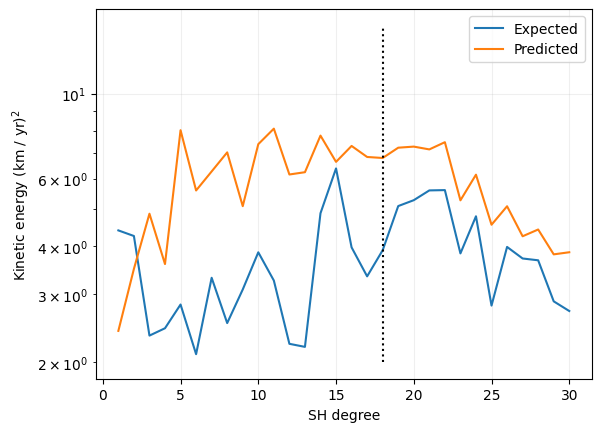

In [ ]:
l = numpy.arange(0, l_trunc + 1, 1)

plt.plot(l[1:], S_u_obs[1:], label="Expected")
plt.plot(l[1:], S_pred[1:], label="Predicted")
plt.vlines(18, 2, 15, color="black", linestyle="dotted")

plt.yscale("log")
plt.legend()

plt.grid(alpha=0.2)

plt.xlabel("SH degree")
plt.ylabel("Kinetic energy (km / yr)$^2$")

plt.savefig(f"{folder}spectra.png")